In [ ]:
!pip -q install tensorflow scikit-learn pandas matplotlib

In [ ]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Conv1D, MaxPooling1D, Flatten, BatchNormalization,
    InputLayer
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Tekrarlanabilirlik
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
import urllib.request

train_url = "https://raw.githubusercontent.com/HoaNP/NSL-KDD-DataSet/master/KDDTrain%2B.txt"
test_url  = "https://raw.githubusercontent.com/HoaNP/NSL-KDD-DataSet/master/KDDTest%2B.txt"

train_path = "KDDTrain+.txt"
test_path = "KDDTest+.txt"

if not os.path.exists(train_path):
    urllib.request.urlretrieve(train_url, train_path)

if not os.path.exists(test_path):
    urllib.request.urlretrieve(test_url, test_path)

print("Dosyalar indirildi:")
print(os.path.abspath(train_path))
print(os.path.abspath(test_path))

Dosyalar indirildi:
/content/KDDTrain+.txt
/content/KDDTest+.txt


In [ ]:
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty_level"
]

train_df = pd.read_csv(train_path, names=col_names)
test_df = pd.read_csv(test_path, names=col_names)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

train_df.head()

Train shape: (125973, 43)
Test shape : (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
def to_binary_label(x):
    return 0 if x == "normal" else 1

train_df["target"] = train_df["label"].apply(to_binary_label)
test_df["target"] = test_df["label"].apply(to_binary_label)

print("Train class distribution:")
print(train_df["target"].value_counts())

print("\nTest class distribution:")
print(test_df["target"].value_counts())

Train class distribution:
target
0    67343
1    58630
Name: count, dtype: int64

Test class distribution:
target
1    12833
0     9711
Name: count, dtype: int64


In [ ]:
X_train_df = train_df.drop(columns=["label", "difficulty_level", "target"])
X_test_df  = test_df.drop(columns=["label", "difficulty_level", "target"])

y_train = train_df["target"].values
y_test  = test_df["target"].values

categorical_cols = ["protocol_type", "service", "flag"]
numeric_cols = [c for c in X_train_df.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

X_train = preprocessor.fit_transform(X_train_df)
X_test = preprocessor.transform(X_test_df)

print("Processed X_train shape:", X_train.shape)
print("Processed X_test shape :", X_test.shape)

Processed X_train shape: (125973, 122)
Processed X_test shape : (22544, 122)


In [ ]:
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

input_shape_cnn = X_train_cnn.shape[1:]
print("CNN input shape:", input_shape_cnn)

CNN input shape: (122, 1)


In [ ]:
def plot_history(history, title_prefix="Model"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history.history["loss"], label="Training Loss")
    axes[0].plot(history.history["val_loss"], label="Validation Loss")
    axes[0].set_title(f"{title_prefix} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy
    axes[1].plot(history.history["accuracy"], label="Training Accuracy")
    axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
    axes[1].set_title(f"{title_prefix} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


def evaluate_classifier(model, X_test, y_test, model_name="Model"):
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n===== {model_name} Sonuçları =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"], zero_division=0))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
    disp.plot(cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    }

In [ ]:
def build_cnn_model(input_shape):
    model = Sequential([
        InputLayer(input_shape=input_shape),

        Conv1D(filters=32, kernel_size=3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Conv1D(filters=128, kernel_size=3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

cnn_model = build_cnn_model(input_shape_cnn)
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 122, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 122, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 61, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 286,145 (1.09 MB)

 Trainable params: 285,697 (1.09 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 65s 152ms/step - accuracy: 0.9655 - loss: 0.0961 - val_accuracy: 0.9853 - val_loss: 0.0436 - learning_rate: 0.0010
Epoch 2/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 80s 147ms/step - accuracy: 0.9891 - loss: 0.0300 - val_accuracy: 0.9917 - val_loss: 0.0225 - learning_rate: 0.0010
Epoch 3/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 58s 147ms/step - accuracy: 0.9911 - loss: 0.0242 - val_accuracy: 0.9930 - val_loss: 0.0213 - learning_rate: 0.0010
Epoch 4/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 79s 141ms/step - accuracy: 0.9919 - loss: 0.0208 - val_accuracy: 0.9923 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 5/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 57s 145ms/step - accuracy: 0.9931 - loss: 0.0182 - val_accuracy: 0.9936 - val_loss: 0.0165 - learning_rate: 0.0010
Epoch 6/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 59s 149ms/step - accuracy: 0.9935 - loss: 0.0179 - val_accuracy: 0.9927 - val_loss: 0.0176 - learning_rate: 0.0010
Epoch 7/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 57s 144ms/step - accuracy: 0.9

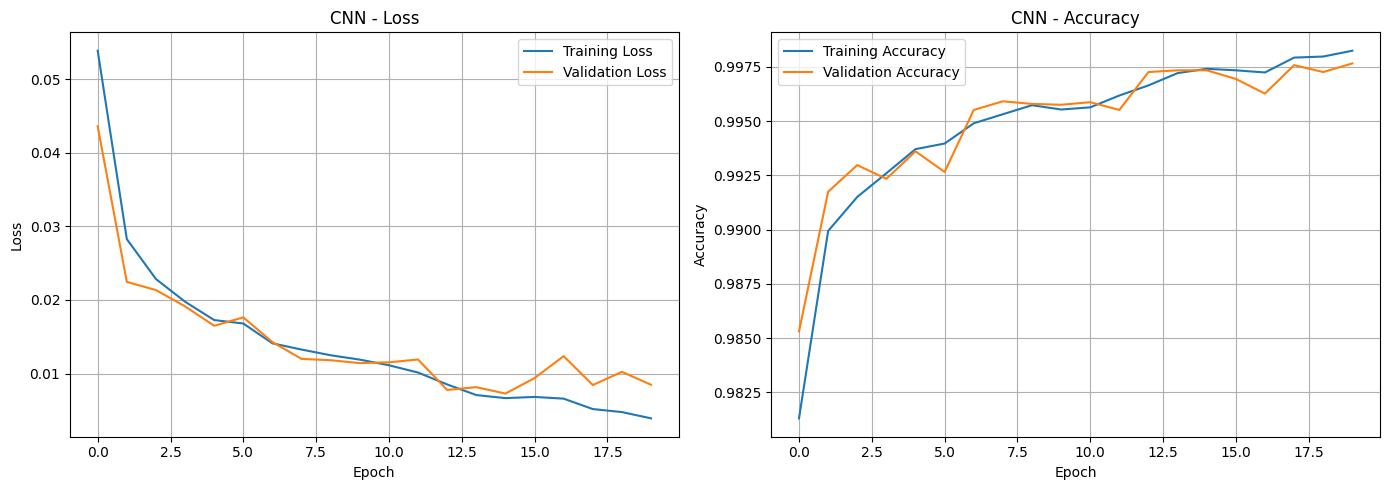


===== CNN Sonuçları =====
Accuracy : 0.7594
Precision: 0.9199
Recall   : 0.6325
F1-score : 0.7496

Classification Report:
              precision    recall  f1-score   support

      Normal       0.66      0.93      0.77      9711
      Attack       0.92      0.63      0.75     12833

    accuracy                           0.76     22544
   macro avg       0.79      0.78      0.76     22544
weighted avg       0.81      0.76      0.76     22544



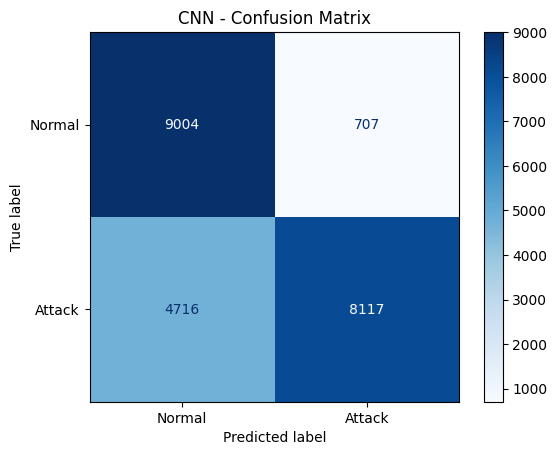

In [ ]:
plot_history(history_cnn, title_prefix="CNN")
cnn_results = evaluate_classifier(cnn_model, X_test_cnn, y_test, model_name="CNN")

In [ ]:
input_dim = X_train.shape[1]
encoding_dim_1 = 128
encoding_dim_2 = 64

# Autoencoder
ae_input = Input(shape=(input_dim,), name="ae_input")

encoded = Dense(encoding_dim_1, activation="relu", name="encoder_dense_1")(ae_input)
encoded = Dense(encoding_dim_2, activation="relu", name="encoder_dense_2")(encoded)

decoded = Dense(encoding_dim_1, activation="relu", name="decoder_dense_1")(encoded)
decoded = Dense(input_dim, activation="linear", name="decoder_output")(decoded)

autoencoder = Model(ae_input, decoded, name="Autoencoder")
encoder = Model(ae_input, encoded, name="Encoder")

autoencoder.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mse"
)

autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input (InputLayer)           │ (None, 122)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 128)            │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 122)            │        15,738 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,058 (187.73 KB)

 Trainable params: 48,058 (187.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ae_callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

history_ae = autoencoder.fit(
    X_train, X_train,
    validation_split=0.2,
    epochs=25,
    batch_size=256,
    callbacks=ae_callbacks,
    verbose=1
)

Epoch 1/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1500 - val_loss: 0.0387 - learning_rate: 0.0010
Epoch 2/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0453 - val_loss: 0.0235 - learning_rate: 0.0010
Epoch 3/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0300 - val_loss: 0.0358 - learning_rate: 0.0010
Epoch 4/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0266 - val_loss: 0.0227 - learning_rate: 0.0010
Epoch 5/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0279 - val_loss: 0.0252 - learning_rate: 0.0010
Epoch 6/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0310 - val_loss: 0.0154 - learning_rate: 0.0010
Epoch 7/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0190 - val_loss: 0.0156 - learning_rate: 0.0010
Epoch 8/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0188 - val_loss: 0.0142 - learning_rate: 0.0010
Epoch 9/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0180 - val_loss: 0.0134 - learning_rate: 0.0010
Epoch 10/2

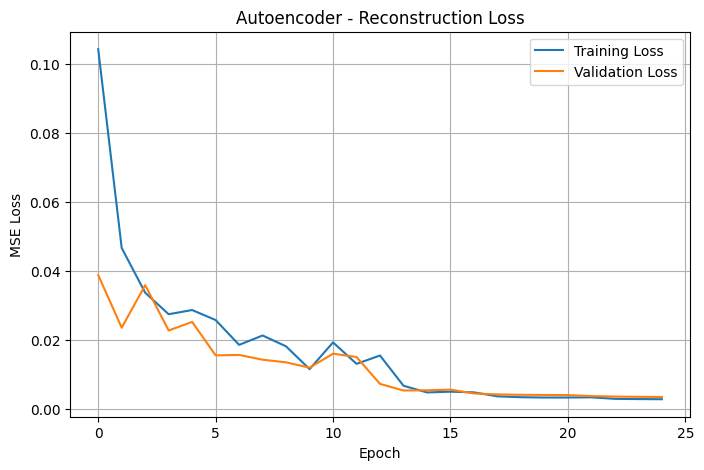

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_ae.history["loss"], label="Training Loss")
plt.plot(history_ae.history["val_loss"], label="Validation Loss")
plt.title("Autoencoder - Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
X_train_encoded = encoder.predict(X_train, verbose=0)
X_test_encoded = encoder.predict(X_test, verbose=0)

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape :", X_test_encoded.shape)

Encoded train shape: (125973, 64)
Encoded test shape : (22544, 64)


In [ ]:
X_train_aecnn = X_train_encoded.reshape((X_train_encoded.shape[0], X_train_encoded.shape[1], 1))
X_test_aecnn  = X_test_encoded.reshape((X_test_encoded.shape[0], X_test_encoded.shape[1], 1))

input_shape_aecnn = X_train_aecnn.shape[1:]
print("AE-CNN input shape:", input_shape_aecnn)

AE-CNN input shape: (64, 1)


In [ ]:
def build_ae_cnn_model(input_shape):
    model = Sequential([
        InputLayer(input_shape=input_shape),

        Conv1D(filters=32, kernel_size=3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        Flatten(),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

ae_cnn_model = build_ae_cnn_model(input_shape_aecnn)
ae_cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 64, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 32, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,433 (290.75 KB)

 Trainable params: 74,241 (290.00 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
callbacks_aecnn = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

history_aecnn = ae_cnn_model.fit(
    X_train_aecnn, y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=256,
    callbacks=callbacks_aecnn,
    verbose=1
)

Epoch 1/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.9576 - loss: 0.1145 - val_accuracy: 0.9859 - val_loss: 0.0380 - learning_rate: 0.0010
Epoch 2/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.9887 - loss: 0.0317 - val_accuracy: 0.9907 - val_loss: 0.0230 - learning_rate: 0.0010
Epoch 3/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.9909 - loss: 0.0248 - val_accuracy: 0.9925 - val_loss: 0.0208 - learning_rate: 0.0010
Epoch 4/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.9913 - loss: 0.0225 - val_accuracy: 0.9920 - val_loss: 0.0202 - learning_rate: 0.0010
Epoch 5/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.9915 - loss: 0.0215 - val_accuracy: 0.9929 - val_loss: 0.0180 - learning_rate: 0.0010
Epoch 6/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.9925 - loss: 0.0188 - val_accuracy: 0.9927 - val_loss: 0.0200 - learning_rate: 0.0010
Epoch 7/25
394/394 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.9923 - l

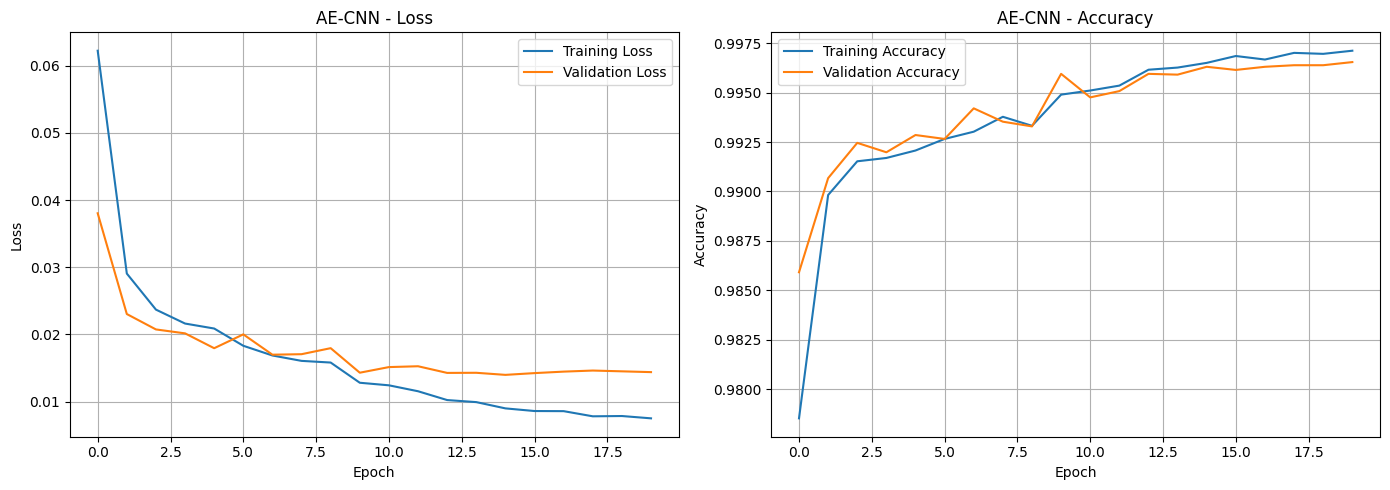


===== AE-CNN Sonuçları =====
Accuracy : 0.7774
Precision: 0.9677
Recall   : 0.6299
F1-score : 0.7631

Classification Report:
              precision    recall  f1-score   support

      Normal       0.67      0.97      0.79      9711
      Attack       0.97      0.63      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.77     22544



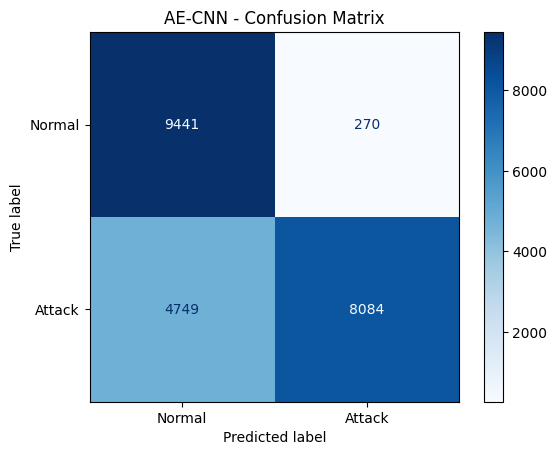

In [ ]:
plot_history(history_aecnn, title_prefix="AE-CNN")
aecnn_results = evaluate_classifier(ae_cnn_model, X_test_aecnn, y_test, model_name="AE-CNN")

In [ ]:
print("\n===== Model Karşılaştırması =====")
print(results_df.to_string(index=False))


===== Model Karşılaştırması =====
 Model  Accuracy  Precision   Recall  F1-score
   CNN  0.759448   0.919878 0.632510  0.749596
AE-CNN  0.777369   0.967680 0.629938  0.763109


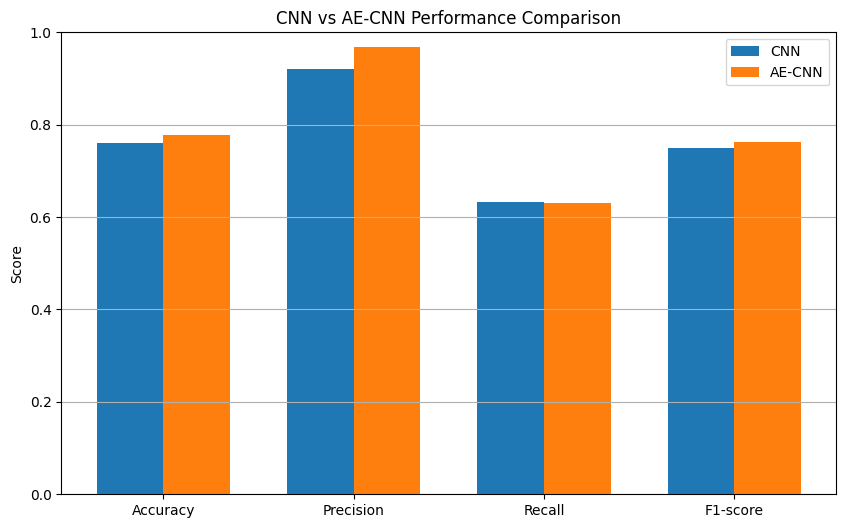

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

plt.figure(figsize=(10,6))
x = np.arange(len(metrics))
width = 0.35

cnn_vals = [cnn_results[m] for m in metrics]
aecnn_vals = [aecnn_results[m] for m in metrics]

plt.bar(x - width/2, cnn_vals, width, label="CNN")
plt.bar(x + width/2, aecnn_vals, width, label="AE-CNN")

plt.xticks(x, metrics)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("CNN vs AE-CNN Performance Comparison")
plt.legend()
plt.grid(axis="y")
plt.show()

In [ ]:
!pip -q install tensorflow scikit-learn pandas matplotlib

In [ ]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve
)

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
import urllib.request

train_url = "https://raw.githubusercontent.com/HoaNP/NSL-KDD-DataSet/master/KDDTrain%2B.txt"
test_url  = "https://raw.githubusercontent.com/HoaNP/NSL-KDD-DataSet/master/KDDTest%2B.txt"

train_path = "KDDTrain+.txt"
test_path = "KDDTest+.txt"

if not os.path.exists(train_path):
    urllib.request.urlretrieve(train_url, train_path)

if not os.path.exists(test_path):
    urllib.request.urlretrieve(test_url, test_path)

print("Dosyalar indirildi:")
print(os.path.abspath(train_path))
print(os.path.abspath(test_path))

Dosyalar indirildi:
/content/KDDTrain+.txt
/content/KDDTest+.txt


In [ ]:
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty_level"
]

train_df = pd.read_csv(train_path, names=col_names)
test_df = pd.read_csv(test_path, names=col_names)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
train_df.head()

Train shape: (125973, 43)
Test shape : (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
def to_binary_label(x):
    return 0 if x == "normal" else 1

train_df["target"] = train_df["label"].apply(to_binary_label)
test_df["target"] = test_df["label"].apply(to_binary_label)

print("Train class distribution:")
print(train_df["target"].value_counts())

print("\nTest class distribution:")
print(test_df["target"].value_counts())

Train class distribution:
target
0    67343
1    58630
Name: count, dtype: int64

Test class distribution:
target
1    12833
0     9711
Name: count, dtype: int64


In [ ]:
X_train_df = train_df.drop(columns=["label", "difficulty_level", "target"])
X_test_df  = test_df.drop(columns=["label", "difficulty_level", "target"])

y_train = train_df["target"].values
y_test  = test_df["target"].values

categorical_cols = ["protocol_type", "service", "flag"]
numeric_cols = [c for c in X_train_df.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

X_train = preprocessor.fit_transform(X_train_df)
X_test = preprocessor.transform(X_test_df)

print("Processed X_train shape:", X_train.shape)
print("Processed X_test shape :", X_test.shape)

Processed X_train shape: (125973, 122)
Processed X_test shape : (22544, 122)


In [ ]:
X_train_normal = X_train[y_train == 0]
X_test_all = X_test
y_test_all = y_test

print("Only normal training samples:", X_train_normal.shape)
print("All test samples:", X_test_all.shape)

Only normal training samples: (67343, 122)
All test samples: (22544, 122)


In [ ]:
from sklearn.model_selection import train_test_split

X_train_normal_part, X_val_normal = train_test_split(
    X_train_normal,
    test_size=0.2,
    random_state=SEED
)

print("Train normal:", X_train_normal_part.shape)
print("Validation normal:", X_val_normal.shape)

Train normal: (53874, 122)
Validation normal: (13469, 122)


In [ ]:
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [ ]:
input_dim = X_train.shape[1]
latent_dim = 16
hidden_dim_1 = 128
hidden_dim_2 = 64

# Encoder
encoder_inputs = Input(shape=(input_dim,), name="encoder_input")
x = Dense(hidden_dim_1, activation="relu")(encoder_inputs)
x = Dense(hidden_dim_2, activation="relu")(x)

z_mean = Dense(latent_dim, name="z_mean")(x)
z_log_var = Dense(latent_dim, name="z_log_var")(x)
z = Lambda(sampling, name="z")([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Decoder
latent_inputs = Input(shape=(latent_dim,), name="z_sampling")
x = Dense(hidden_dim_2, activation="relu")(latent_inputs)
x = Dense(hidden_dim_1, activation="relu")(x)
decoder_outputs = Dense(input_dim, activation="linear")(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")

In [ ]:
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(data - reconstruction), axis=1)
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(data - reconstruction), axis=1)
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )

        total_loss = reconstruction_loss + kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer=Adam(learning_rate=1e-3))

encoder.summary()
decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 122)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     15,744 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 16)        │      1,040 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 16)        │      1,040 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 16)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,080 (101.88 KB)

 Trainable params: 26,080 (101.88 KB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 122)            │        15,738 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,146 (98.23 KB)

 Trainable params: 25,146 (98.23 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

history = vae.fit(
    X_train_normal_part,
    validation_data=(X_val_normal, None),
    epochs=30,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 74042107232256.0000 - loss: 89026367324160.0000 - reconstruction_loss: 14984256946176.0000 - val_kl_loss: 1.6454 - val_loss: 32.8624 - val_reconstruction_loss: 31.2170 - learning_rate: 0.0010
Epoch 2/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - kl_loss: 11734.8359 - loss: 13040.0029 - reconstruction_loss: 1305.1650 - val_kl_loss: 3.2862 - val_loss: 28.5452 - val_reconstruction_loss: 25.2590 - learning_rate: 0.0010
Epoch 3/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - kl_loss: 2980740.5000 - loss: 3185210.2500 - reconstruction_loss: 204473.2188 - val_kl_loss: 3.3182 - val_loss: 27.1349 - val_reconstruction_loss: 23.8167 - learning_rate: 0.0010
Epoch 4/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - kl_loss: 141.0087 - loss: 211.8230 - reconstruction_loss: 70.8142 - val_kl_loss: 3.5072 - val_loss: 26.7527 - val_reconstruction_loss: 23.2455 - learning_rate: 0.0010
Epoch 5/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - kl_loss: 

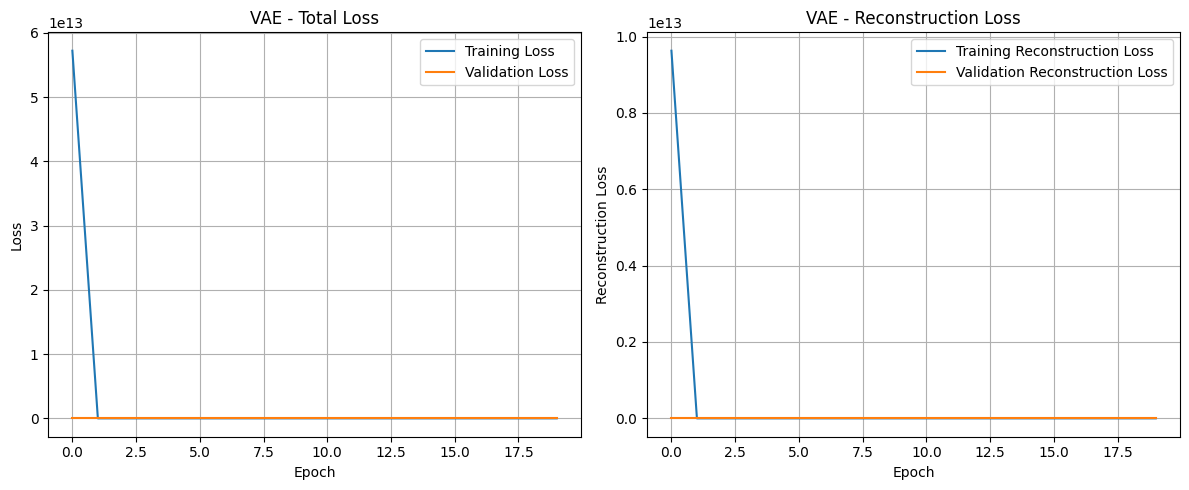

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("VAE - Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history["reconstruction_loss"], label="Training Reconstruction Loss")
plt.plot(history.history["val_reconstruction_loss"], label="Validation Reconstruction Loss")
plt.title("VAE - Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def reconstruct_data(model, data):
    z_mean, z_log_var, z = model.encoder.predict(data, verbose=0)
    reconstructed = model.decoder.predict(z, verbose=0)
    return reconstructed

def reconstruction_errors(model, data):
    reconstructed = reconstruct_data(model, data)
    errors = np.mean(np.square(data - reconstructed), axis=1)
    return errors

In [ ]:
val_errors = reconstruction_errors(vae, X_val_normal)
test_errors = reconstruction_errors(vae, X_test_all)

print("Validation errors shape:", val_errors.shape)
print("Test errors shape:", test_errors.shape)

Validation errors shape: (13469,)
Test errors shape: (22544,)


In [ ]:
threshold = np.percentile(val_errors, 95)

print("Selected threshold:", threshold)

Selected threshold: 0.1563994574758622


In [ ]:
y_pred = (test_errors > threshold).astype(int)

print("Predicted anomalies:", np.sum(y_pred == 1))
print("Predicted normals:", np.sum(y_pred == 0))

Predicted anomalies: 8175
Predicted normals: 14369


In [ ]:
def false_positive_rate(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return fp / (fp + tn)

roc_auc = roc_auc_score(y_test_all, test_errors)
precision = precision_score(y_test_all, y_pred, zero_division=0)
recall = recall_score(y_test_all, y_pred, zero_division=0)
f1 = f1_score(y_test_all, y_pred, zero_division=0)
fpr = false_positive_rate(y_test_all, y_pred)

print("===== VAE Anomaly Detection Results =====")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"FPR      : {fpr:.4f}")

===== VAE Anomaly Detection Results =====
ROC-AUC  : 0.9088
Precision: 0.9096
Recall   : 0.5794
F1-score : 0.7079
FPR      : 0.0761


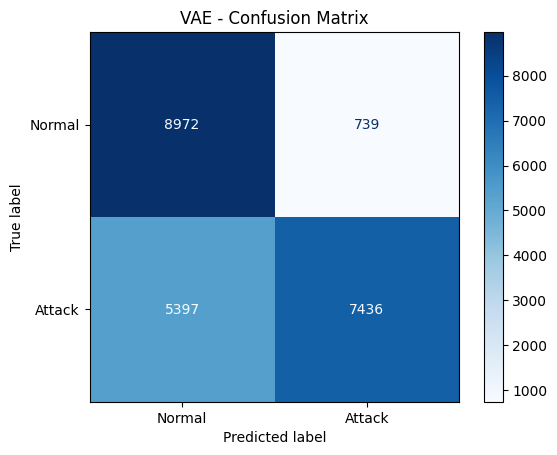

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
disp.plot(cmap="Blues")
plt.title("VAE - Confusion Matrix")
plt.show()

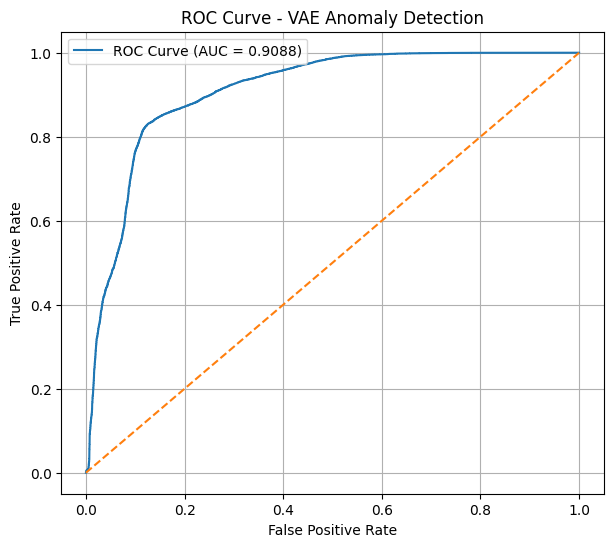

In [ ]:
fpr_curve, tpr_curve, _ = roc_curve(y_test_all, test_errors)

plt.figure(figsize=(7,6))
plt.plot(fpr_curve, tpr_curve, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - VAE Anomaly Detection")
plt.legend()
plt.grid(True)
plt.show()

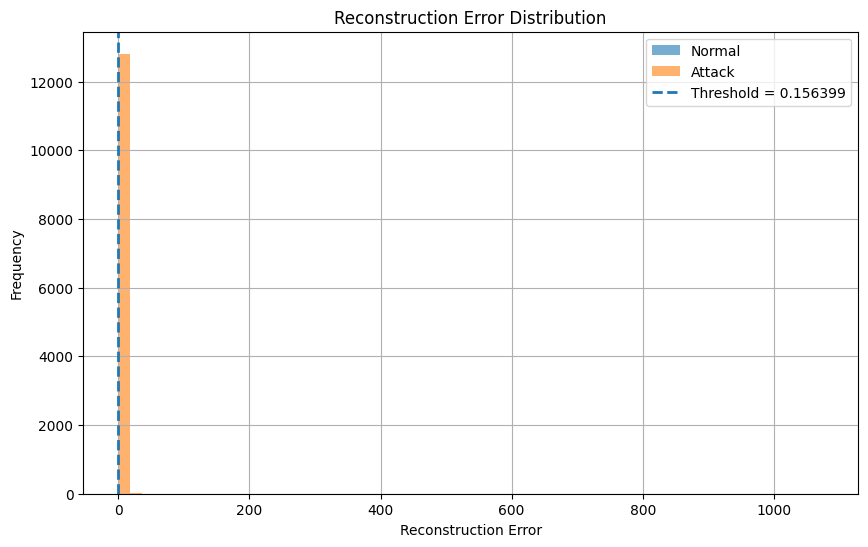

In [ ]:
normal_errors = test_errors[y_test_all == 0]
attack_errors = test_errors[y_test_all == 1]

plt.figure(figsize=(10,6))
plt.hist(normal_errors, bins=60, alpha=0.6, label="Normal")
plt.hist(attack_errors, bins=60, alpha=0.6, label="Attack")
plt.axvline(threshold, linestyle="--", linewidth=2, label=f"Threshold = {threshold:.6f}")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.grid(True)
plt.show()

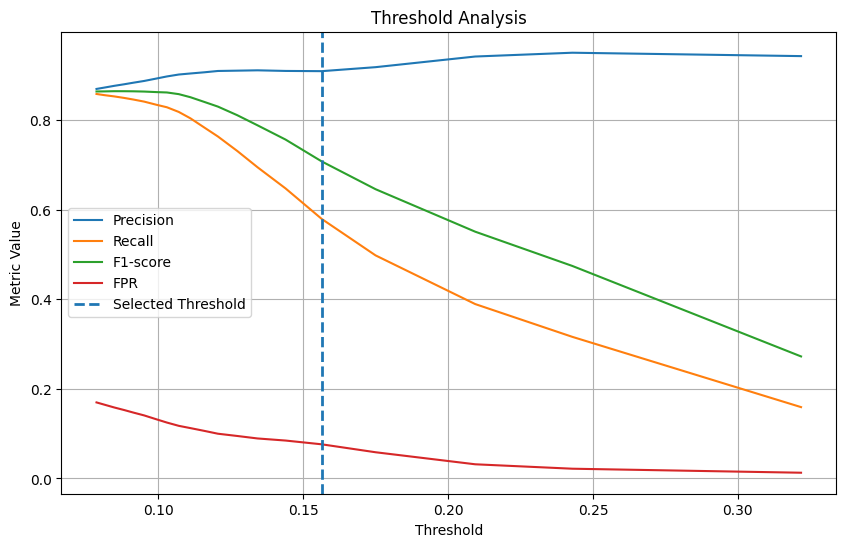

In [ ]:
thresholds = np.percentile(val_errors, np.arange(80, 100, 1))

precision_list = []
recall_list = []
f1_list = []
fpr_list = []

for th in thresholds:
    temp_pred = (test_errors > th).astype(int)

    precision_list.append(precision_score(y_test_all, temp_pred, zero_division=0))
    recall_list.append(recall_score(y_test_all, temp_pred, zero_division=0))
    f1_list.append(f1_score(y_test_all, temp_pred, zero_division=0))
    fpr_list.append(false_positive_rate(y_test_all, temp_pred))

plt.figure(figsize=(10,6))
plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, recall_list, label="Recall")
plt.plot(thresholds, f1_list, label="F1-score")
plt.plot(thresholds, fpr_list, label="FPR")
plt.axvline(threshold, linestyle="--", linewidth=2, label="Selected Threshold")
plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.title("Threshold Analysis")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
results_df = pd.DataFrame([{
    "Model": "VAE Anomaly Detection",
    "ROC-AUC": roc_auc,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "FPR": fpr,
    "Threshold": threshold
}])

results_df

,Model,ROC-AUC,Precision,Recall,F1-score,FPR,Threshold
0,VAE Anomaly Detection,0.908788,0.909602,0.579444,0.707921,0.076099,0.156399


In [ ]:
print(results_df.to_string(index=False))

                Model  ROC-AUC  Precision   Recall  F1-score      FPR  Threshold
VAE Anomaly Detection 0.908788   0.909602 0.579444  0.707921 0.076099   0.156399
